In [80]:
import numpy as np
from PyFingerprint.fingerprint import get_fingerprint

#combo_types = ['morgan', 'estate', 'extended', 'cdk-substructure', 'cdk-atompairs', 'klekota-roth', 'spectrophore']
#combo_types = ['morgan', 'estate', 'extended', 'spectrophore']
combo_types = ['topological-torsion', 'hybridization', 'morgan', 'extended', 'fp2']



fp_types = {'standard': 1024, 'extended': 1024, 'maccs': 166, 'pubchem': 881, 'morgan': 2048, 'fp2': 1024, 'spectrophore': 48, 'rdkit': 2048, 'rdk-maccs': 167, 'topological-torsion': 2048, 'avalon': 512, 'atom-pair': 2048, 'rdk-descriptor': 211, 'graph': 1024, 'estate': 79, 'hybridization': 1024, 'lingo': 1024, 'shortestpath': 1024, 'cdk-substructure': 307, 'circular': 1024, 'cdk-atompairs': 780, 'mol2vec' : 300}
def get_combo_info(c):
    s = ''
    length = 0
    for i in combo_types:
        s = s + i + " "
        length += fp_types.get(i)
    
    return s, length


s, l = get_combo_info(combo_types)
combo = {s : l}

cdktypes = ['standard', 'extended', 'graph', 'maccs', 'pubchem', 'estate', 'hybridization', 'lingo', 
            'klekota-roth', 'shortestpath', 'cdk-substructure', 'circular', 'cdk-atompairs']
rdktypes = ['rdkit', 'morgan', 'rdk-maccs', 'topological-torsion', 'avalon', 'atom-pair', 'rdk-descriptor']
babeltypes = ['fp2', 'fp3', 'fp4', 'spectrophore', 'mol2vec']

types = babeltypes + rdktypes + cdktypes
i = 0
def featurize(smiles, T):
    global i
    i += 1
    #if not i%10:
        #print(f"{i} molecules completed")
    r = []
    j = T.split()
    for t in j:
        finger = list(get_fingerprint(smiles, t).to_numpy())
        if t == 'rdk-descriptor':
            if finger[42] is not None and finger[42] > np.finfo(np.float32).max:
                finger[42] = np.finfo(np.float32).max
        r += finger
    return r

In [81]:
from sklearn.metrics import r2_score

def evaluate_model(m, y_actual, y_train_actual, X_t, X_tr, name):    
    y_pred = m.predict(X_t)
    r2 = r2_score(y_actual, y_pred)

    train_pred = m.predict(X_tr)
    r2_train = r2_score(y_train_actual, train_pred)

    #visualize_results(y_pred, y_actual, name)
    #visualize_results(train_pred, y_train_actual, name)
    print(f"r2 test set {r2}")
    #print(f"r2 train set {r2_train}")

    return [f"r2 test set {r2}", f" r2 train set {r2_train}"]

In [82]:
import pandas as pd

def get_x_y(fp_type, labels, use_ic50=True):
    if use_ic50:
        target_type = 'IC50 (nM)'
    else:
        target_type = 'Ki (nM)'
    df = pd.read_csv('yhtrum7002_gmail.com5765.tsv', sep='\t')
    wanted_columns = ['Ligand SMILES', target_type]
    df = df[wanted_columns]
    df = df.dropna(subset=[target_type])
    df[target_type] = df[target_type].apply(clean_val)
    df = df.dropna(subset=[target_type])
    df['IC50_nM_float'] = pd.to_numeric(df['IC50 (nM)'], errors='coerce')
    df = df.dropna(subset=['IC50_nM_float'])
    df['IC50 (M)'] = df['IC50_nM_float'] / 1e9
    df['pIC50'] = -np.log10(df['IC50 (M)'])

    for column in df.columns:
        print(f"{column} : {df[column].notna().sum()}")
    print(df.columns)
    
    df['features'] = df['Ligand SMILES'].apply(lambda smil : featurize(smil, fp_type))
    features_df = pd.DataFrame(df['features'].tolist(), columns=labels)

    all_zero_columns = features_df.columns[(features_df == 0).all()]
    all_one_columns = features_df.columns[(features_df == 1).all()]
    removed_columns = list(all_zero_columns) + list(all_one_columns)

    features_df = features_df.drop(columns=removed_columns)

    print(f"removed {len(removed_columns)}")
    print(f"Removed columns: {removed_columns}")

    # labels = [item for item in labels if item not in removed_columns]

    X = features_df
    y = df['pIC50']

    return X, y, removed_columns, df

import re
def clean_val(value):
    was_cleaned = bool(re.search(r'^[<>]', value))
    val = re.sub(r'^[^\d]+', '', value)

    if float(val) > 4999 and was_cleaned:
        return None
    else:
        return val

In [83]:
import json

def read_json_file(file_path):
    try:
        with open(file_path, 'r') as f:
            data = f.read()
            if not data:
                return []
            return json.loads(data)
    except FileNotFoundError:
        return []
    except json.JSONDecodeError:
        return []

def append_or_merge_to_json_file(file_path, new_data):
    existing_data = read_json_file(file_path)
    if not isinstance(existing_data, list):
        existing_data = [existing_data]

    if existing_data:
        last_entry = existing_data[-1]
        for key, value in new_data.items():
            last_entry[key] = value
    else:
        existing_data.append(new_data)

    with open(file_path, 'w') as f:
        json.dump(existing_data, f, indent=4)

In [84]:
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import random

def main(s_split=45, s_model=62, use_custom_states=True):
    t = combo
    results = {}
    for fp_type in tqdm(t.keys()):
        print(fp_type)
        labels = [f'fp_{i}' for i in range(t.get(fp_type))]
        print(t.get(fp_type))
        X, y, removed_cols, df = get_x_y(fp_type, labels, True) # type: ignore
        r2s = ["r2 test set 0"]

        if use_custom_states: epochs = 1
        else: epochs = 200
        for epoch in range(epochs):
            split_state = 0
            model_state = 0
            if not use_custom_states:
                split_state = random.randint(0, 300)
                model_state =   random.randint(0, 300)
            else:
                split_state = s_split
                model_state = s_model
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=split_state)


            model = RandomForestRegressor(random_state=model_state, n_estimators=400, max_depth=50, max_features='sqrt', min_samples_leaf=2, min_samples_split=2)

            model.fit(X_train, y_train)
            data = evaluate_model(model, y_test, y_train, X_test, X_train, fp_type)
            
            if float(data[0][11:]) > float(r2s[0][11:]):
                data.append(f"split state: {split_state}")
                data.append(f"model state: {model_state}")
                r2s = data.copy()

            import pickle

            with open("new_model.pkl", 'wb') as file:
                pickle.dump(model, file)
            
            with open("new_removed_cols.pkl", 'wb') as file:
                # These are the columns removed from the featurized data
                pickle.dump(removed_cols, file)
            
            return model, y_test, X_test, df


        results[fp_type] = r2s
        append_or_merge_to_json_file("pic50_results.json", results) # type: ignore
        print(removed_cols)


#main(242, 267, True)
model, y_test, X_test, df = main(242, 267, True)

  0%|          | 0/1 [00:00<?, ?it/s]

topological-torsion hybridization morgan extended fp2 
7168
Ligand SMILES : 3109
IC50 (nM) : 3109
IC50_nM_float : 3109
IC50 (M) : 3109
pIC50 : 3109
Index(['Ligand SMILES', 'IC50 (nM)', 'IC50_nM_float', 'IC50 (M)', 'pIC50'], dtype='object')
removed 832
Removed columns: ['fp_3', 'fp_8', 'fp_9', 'fp_10', 'fp_11', 'fp_12', 'fp_13', 'fp_14', 'fp_17', 'fp_19', 'fp_20', 'fp_22', 'fp_23', 'fp_25', 'fp_26', 'fp_29', 'fp_33', 'fp_42', 'fp_43', 'fp_44', 'fp_45', 'fp_46', 'fp_51', 'fp_52', 'fp_53', 'fp_58', 'fp_59', 'fp_60', 'fp_64', 'fp_72', 'fp_74', 'fp_75', 'fp_76', 'fp_79', 'fp_98', 'fp_99', 'fp_101', 'fp_111', 'fp_123', 'fp_124', 'fp_139', 'fp_141', 'fp_148', 'fp_151', 'fp_156', 'fp_164', 'fp_165', 'fp_173', 'fp_175', 'fp_180', 'fp_181', 'fp_186', 'fp_187', 'fp_189', 'fp_194', 'fp_195', 'fp_196', 'fp_197', 'fp_198', 'fp_204', 'fp_205', 'fp_208', 'fp_210', 'fp_212', 'fp_214', 'fp_216', 'fp_218', 'fp_219', 'fp_229', 'fp_230', 'fp_231', 'fp_233', 'fp_234', 'fp_236', 'fp_237', 'fp_238', 'fp_239',

  0%|          | 0/1 [07:04<?, ?it/s]

r2 test set 0.8263184735800286


In [85]:
import math
y_test_float = pd.to_numeric(y_test, errors='coerce')
y_pred = model.predict(X_test)


In [86]:
print(r2_score(y_test_float, y_pred))

0.8263184735800286


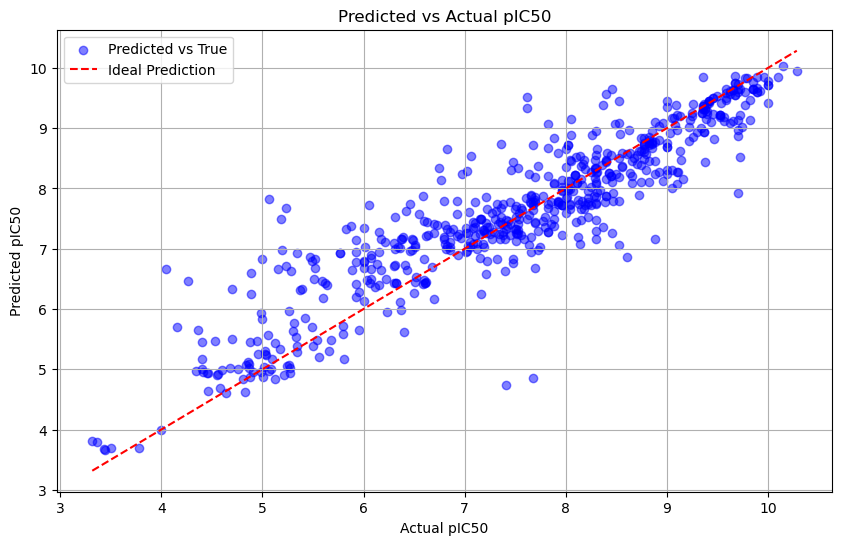

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_test_float, y_pred, label='Predicted vs True', color='blue', alpha=0.5)

# Line with slope 1 going through (0, 0)
min_val = min(y_test_float.min(), y_pred.min())
max_val = max(y_test_float.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction')

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title('Predicted vs Actual pIC50')
plt.legend()
plt.grid(True)
plt.show()